# Baseline Models

In this notebook, we set up our baseline models using Linear Regression and K-Nearest Neighbors (KNN). We use a smaller subset of our training data to quickly tune hyperparameters before applying the final settings to the full dataset. Establishing these baselines helps us measure how much improvement we get from more advanced non-linear architectures later.

In [1]:
import numpy as np
import pickle
import utils

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

with open('data/dataset_clean.pkl', 'rb') as file:
    X_train, X_val, X_test, y_train, y_val, y_test = pickle.load(file)['retval']

# Combine train and val data for final testing across all models
X_train_combined = np.vstack((X_train, X_val))
y_train_combined = np.concatenate((y_train, y_val))

## 1. Linear Regression
### 1.1 Initialization

A standard linear regression model serves as our baseline. It assumes a linear relationship between color indices and redshift, meaning it doesn't need feature scaling or hyperparameter tuning. Given the curving nature of the redshift track, we expect this model to have a high outlier fraction and NMAD.

In [2]:
#Initialize the model
lin_model = LinearRegression().fit(X_train, y_train)

### 1.2 Validation Set Evaluation

Now we test the linear model on the unseen validation set. This initial check lets us calculate standard metrics like outlier fraction, bias, and NMAD to see how much the galaxy data violates the linear assumption.

In [3]:
# Make predictions on the validation set
z_pred_val_lin = lin_model.predict(X_val)

# Print the metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
utils.metrics(z_pred_val_lin, y_val)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0833610934455851
Bias:             0.0010983280371875
NMAD:             0.0279943794012070


### 1.3 Test Set Evaluation

Finally, we evaluate on the held-out test set. We combine the training and validation sets before this final fit to give the model as much data as possible. These test predictions lock in our official baseline metrics.

In [4]:
print("=" * 36)
print("FINAL TEST SET EVALUATION")
print("=" * 36 + "\n")

# Re-fit the model on the new training set and make predictions on test set
lin_model.fit(np.array(X_train_combined), np.array(y_train_combined)) 
z_pred_test_lin = lin_model.predict(np.array(X_test))

# Print metrics
print( "-" * 7, f"Test Dataset Metrics", "-" * 7)
utils.metrics(z_pred_test_lin, y_test)

FINAL TEST SET EVALUATION

------- Test Dataset Metrics -------
Outlier Fraction: 0.0801300169587337
Bias:             0.0011632561217993
NMAD:             0.0277943983674049


## 2. K-Nearest Neighbors (KNN)
### 2.1 Initialization and Optimization

KNN works well for this task because it essentially looks up similar galaxies in color space. However, it requires feature scaling to ensure all colors are weighted equally in the distance calculation. We use a Pipeline with a `StandardScaler` and run a grid search on a smaller tuning subset to find the best number of neighbors.

----- Running GridSearchCV -----
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/Users/manthanp/astroML/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Total Runtime: 1.4091 minutes

BEST PARAMETERS:  {'knn__algorithm': 'kd_tree', 'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance'}
BEST CV RMSE:    0.0233276714508581


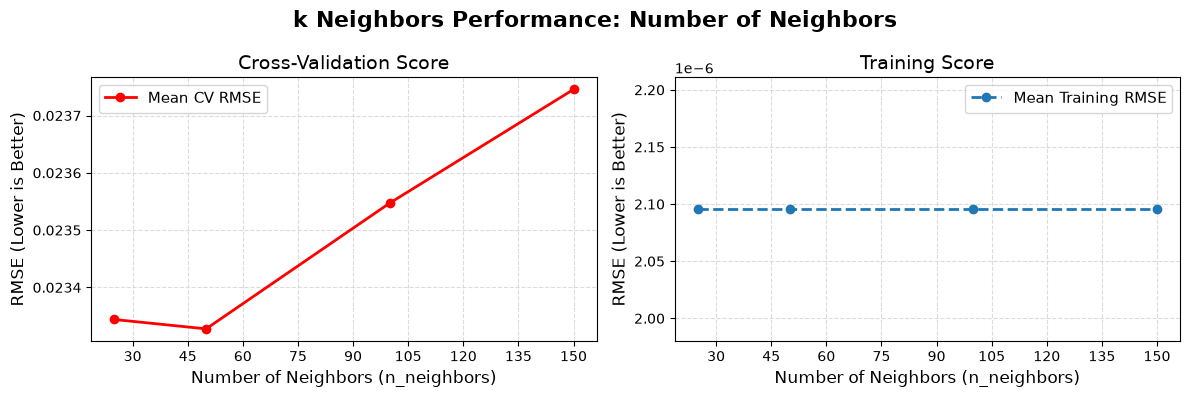

In [5]:
# Create a tuning subset to save time
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=100000, random_state=42)

# Build a Pipeline (scaler + model)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsRegressor())
])

# Define the hyperparameter search space
knn_param_grid = {
    'knn__n_neighbors': [25, 50, 100, 150], 
    'knn__algorithm': ['kd_tree', 'ball_tree'],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] 
}

# Run the search using custom function
knn_search, best_params, best_score = utils.optimize_hyper_params(knn_pipeline, X_tune, y_tune, knn_param_grid, 'grid')

print("\nBEST PARAMETERS: ", best_params)
print(f"BEST CV RMSE:    {-best_score:.16f}")

# Diagnostics plot
utils.plot_side_by_side_diagnostics(
    search=knn_search, 
    param_name='knn__n_neighbors', 
    suptitle='k Neighbors Performance: Number of Neighbors',
    xlabel_text='Number of Neighbors (n_neighbors)'
)

### 2.2 Validation Set Evaluation

After finding the best settings, we train a new KNN model on the full training dataset to map out the color-redshift relationship. Predicting on the validation set verifies that our hyperparameters don't overfit the tuning subset.

In [6]:
# Train a new model with the optimial hyperparameters on the full training set
clean_params = {key.replace('knn__', ''): value for key, value in best_params.items()}
knn_final = KNeighborsRegressor(**clean_params, n_jobs=-1)
knn_final.fit(X_train, y_train)

# Make predictions on the validation set
z_pred_val_knn = knn_final.predict(X_val)

# Print metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
utils.metrics(z_pred_val_knn, y_val)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0256604383069360
Bias:             0.0003476790979766
NMAD:             0.0163725930608235


### 2.3 Test Set Evaluation

To finish the baseline phase, we evaluate the tuned KNN on the test set. Training on the combined array gives the model more reference points, creating a denser lookup table and a highly competitive baseline.

In [7]:
print("=" * 36)
print("FINAL TEST SET EVALUATION")
print(f"Using Hyperparameters: \n{best_params}") # Print best hyperparams
print("=" * 36 + "\n")

# Re-fit the model on the new training set and make predictions on test set
knn_final.fit(np.array(X_train_combined), np.array(y_train_combined)) 
z_pred_test_knn = knn_final.predict(np.array(X_test))

# Print metrics
print( "-" * 7, f"Test Dataset Metrics", "-" * 7)
utils.metrics(z_pred_test_lin, y_test)

FINAL TEST SET EVALUATION
Using Hyperparameters: 
{'knn__algorithm': 'kd_tree', 'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance'}

------- Test Dataset Metrics -------
Outlier Fraction: 0.0801300169587337
Bias:             0.0011632561217993
NMAD:             0.0277943983674049


## 3. Comparative Error Analysis

We analyze the validation errors binned by true spectroscopic redshift to identify where our baseline models degrade. Typically, models perform worse at the boundaries of the training distribution.

=== Binned by Redshift ===
---- Linear Regression ----
bin         N         bias                     nmad                     outlier_frac             
0.02-0.05   12131     0.0349318608641624       0.0254946723580360       0.2982441678344737       
0.05-0.08   20352     0.0187902748584747       0.0191251263022423       0.0303164308176101       
0.08-0.10   14466     0.0086438655853271       0.0159009750932455       0.0076731646619660       
0.10-0.15   30557     -0.0073790005408227      0.0162962749600410       0.0231698137906208       
0.15-0.20   15183     -0.0226285215467215      0.0161507111042738       0.0956991371929131       
0.20-0.25   4811      -0.0350713655352592      0.0180988013744354       0.2097277073373519       
0.25-0.30   1285      -0.0496598705649376      0.0196522604674101       0.4303501945525292       




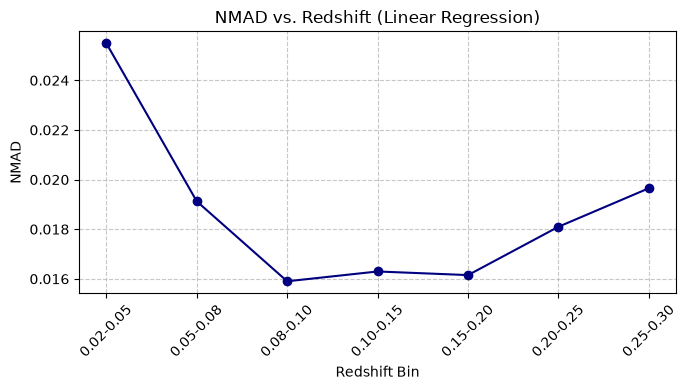

---- K-Nearest Neighbors ----
bin         N         bias                     nmad                     outlier_frac             
0.02-0.05   12131     0.0208390034136272       0.0144350304814448       0.0510262962657654       
0.05-0.08   20352     0.0075127793929375       0.0133169943722530       0.0112519654088050       
0.08-0.10   14466     0.0002051091829621       0.0152802629881972       0.0063597400801880       
0.10-0.15   30557     -0.0063302878520794      0.0161993876664945       0.0252642602349707       
0.15-0.20   15183     -0.0074346391350414      0.0145664170371844       0.0368833563854311       
0.20-0.25   4811      -0.0088610978393234      0.0153093105176828       0.0347121180627728       
0.25-0.30   1285      -0.0128823645929270      0.0145775656610999       0.0529182879377432       




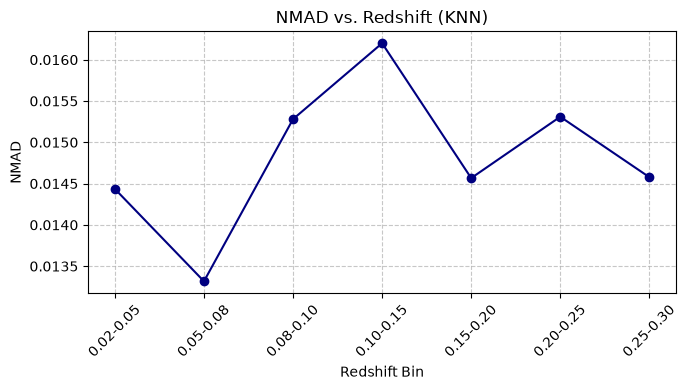

In [8]:
# Create bins for error analysis by redshift for both models
z_bins = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]

print("=== Binned by Redshift ===")
# Linear Regression
utils.binned_metrics(z_pred_val_lin, y_val, z_bins, label="Linear Regression")
utils.plot_binned_metric(
    feature_array=y_val, 
    bins=z_bins, 
    xlabel='Redshift Bin', 
    ylabel='NMAD', 
    title='NMAD vs. Redshift (Linear Regression)', 
    metric_type='nmad', 
    z_pred=z_pred_val_lin, 
    z_true=y_val
)

# KNN
utils.binned_metrics(z_pred_val_knn, y_val, z_bins, label="K-Nearest Neighbors")
utils.plot_binned_metric(
    feature_array=y_val, 
    bins=z_bins, 
    xlabel='Redshift Bin', 
    ylabel='NMAD', 
    title='NMAD vs. Redshift (KNN)', 
    metric_type='nmad', 
    z_pred=z_pred_val_knn, 
    z_true=y_val
)